In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)

# new features
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
df['IsMonthly'] = (df['Contract'] == 'Month-to-month').astype(int)

# encode
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols)

# scale
x = df.drop('Churn', axis=1)
y = df['Churn']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

# balance
sm = SMOTE(random_state=42)
x_bal, y_bal = sm.fit_resample(x_scaled, y)

# split
x_train, x_temp, y_train, y_temp = train_test_split(
    x_bal, y_bal, test_size=0.30, random_state=42, stratify=y_bal)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Data ready!")
print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

/tmp/ipykernel_18079/1279868474.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Data ready!
Train: (7243, 43) Val: (1552, 43) Test: (1553, 43)


Logistic Regression Results:
Accuracy: 0.7784932388924662
              precision    recall  f1-score   support

           0       0.82      0.72      0.76       777
           1       0.75      0.84      0.79       776

    accuracy                           0.78      1553
   macro avg       0.78      0.78      0.78      1553
weighted avg       0.78      0.78      0.78      1553

ROC-AUC: 0.8677639347742441


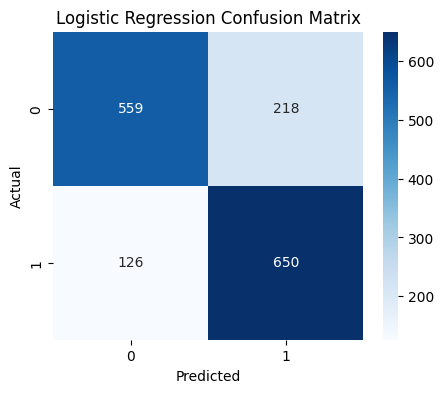

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# train model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(x_train, y_train)

# predict
y_pred_lr = lr.predict(x_test)

# results
print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(x_test)[:,1]))

# confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Decision Tree Results:
Best Params: {'max_depth': 7, 'min_samples_split': 2}
Accuracy: 0.7965228589826143
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       777
           1       0.78      0.83      0.80       776

    accuracy                           0.80      1553
   macro avg       0.80      0.80      0.80      1553
weighted avg       0.80      0.80      0.80      1553

ROC-AUC: 0.8651650545980443


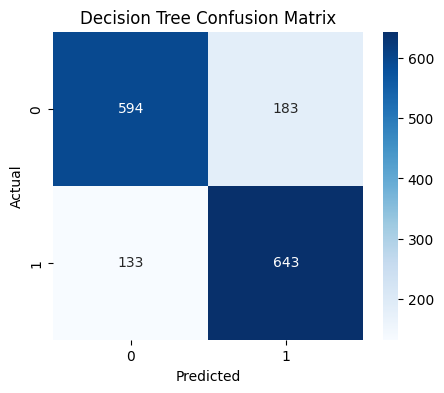

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# hyperparameter tuning
params = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}
dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, params, cv=5, scoring='roc_auc')
grid_dt.fit(x_train, y_train)

# best model
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(x_test)

print("Decision Tree Results:")
print("Best Params:", grid_dt.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, best_dt.predict_proba(x_test)[:,1]))

# confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Random Forest Results:
Best Params: {'max_depth': None, 'n_estimators': 100}
Accuracy: 0.8473921442369607
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       777
           1       0.83      0.88      0.85       776

    accuracy                           0.85      1553
   macro avg       0.85      0.85      0.85      1553
weighted avg       0.85      0.85      0.85      1553

ROC-AUC: 0.9209978572091975


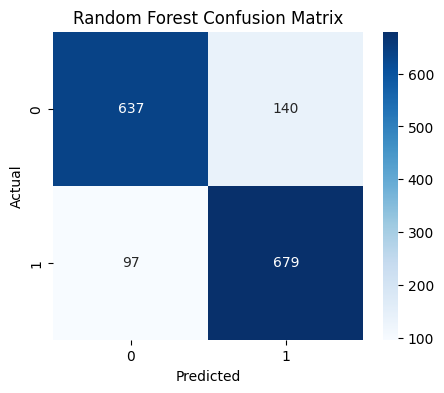

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# hyperparameter tuning
params = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, params, cv=5, scoring='roc_auc')
grid_rf.fit(x_train, y_train)

# best model
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(x_test)

print("Random Forest Results:")
print("Best Params:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(x_test)[:,1]))

# confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

SVM Results:
Best Params: {'C': 10, 'kernel': 'linear'}
Accuracy: 0.7720540888602705
              precision    recall  f1-score   support

           0       0.81      0.71      0.76       777
           1       0.74      0.84      0.79       776

    accuracy                           0.77      1553
   macro avg       0.78      0.77      0.77      1553
weighted avg       0.78      0.77      0.77      1553

ROC-AUC: 0.8631292374849076


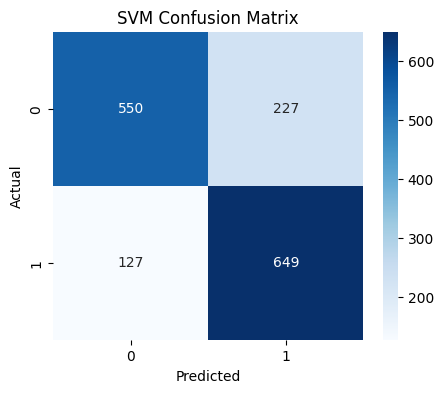

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# smaller param grid to run faster
params = {'C': [1, 10], 'kernel': ['linear']}
svm = SVC(random_state=42, probability=True)
grid_svm = GridSearchCV(svm, params, cv=3, scoring='roc_auc')
grid_svm.fit(x_train, y_train)

# best model
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(x_test)

print("SVM Results:")
print("Best Params:", grid_svm.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, best_svm.predict_proba(x_test)[:,1]))

# confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

KNN Results:
Best Params: {'n_neighbors': 11, 'weights': 'distance'}
Accuracy: 0.8010302640051513
              precision    recall  f1-score   support

           0       0.89      0.68      0.77       777
           1       0.74      0.92      0.82       776

    accuracy                           0.80      1553
   macro avg       0.82      0.80      0.80      1553
weighted avg       0.82      0.80      0.80      1553

ROC-AUC: 0.8773501041542279


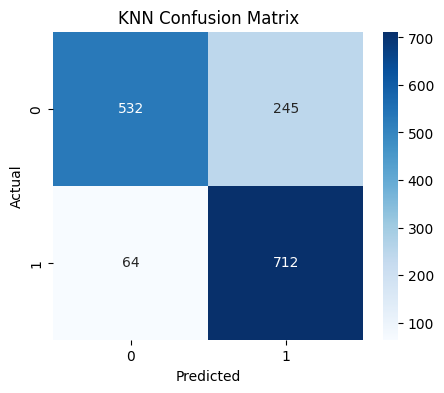

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# hyperparameter tuning
params = {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']}
knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, params, cv=5, scoring='roc_auc')
grid_knn.fit(x_train, y_train)

# best model
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(x_test)

print("KNN Results:")
print("Best Params:", grid_knn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, best_knn.predict_proba(x_test)[:,1]))

# confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

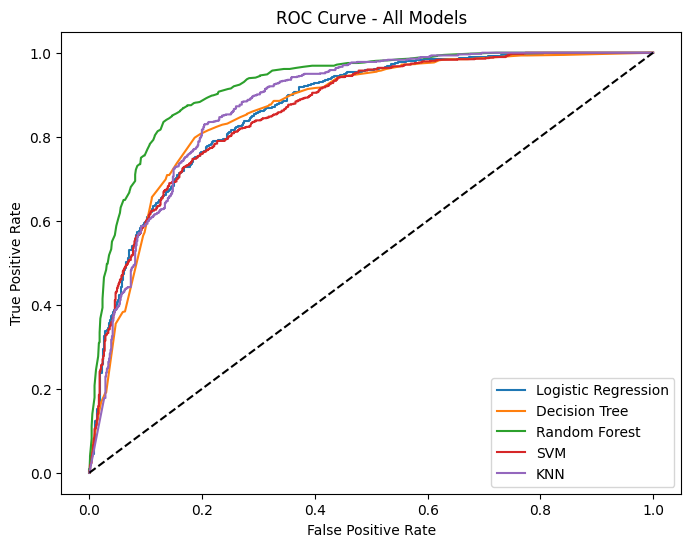

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# plot each model
for name, model in [('Logistic Regression', lr),
                     ('Decision Tree', best_dt),
                     ('Random Forest', best_rf),
                     ('SVM', best_svm),
                     ('KNN', best_knn)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(x_test)[:,1])
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# collect results for all models
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_knn)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_knn)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr.predict_proba(x_test)[:,1]),
        roc_auc_score(y_test, best_dt.predict_proba(x_test)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(x_test)[:,1]),
        roc_auc_score(y_test, best_svm.predict_proba(x_test)[:,1]),
        roc_auc_score(y_test, best_knn.predict_proba(x_test)[:,1])
    ]
}

# show as table
comparison = pd.DataFrame(results)
comparison = comparison.round(3)
print(comparison.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.778      0.749   0.838     0.791    0.868
      Decision Tree     0.797      0.778   0.829     0.803    0.865
      Random Forest     0.847      0.829   0.875     0.851    0.921
                SVM     0.772      0.741   0.836     0.786    0.863
                KNN     0.801      0.744   0.918     0.822    0.877


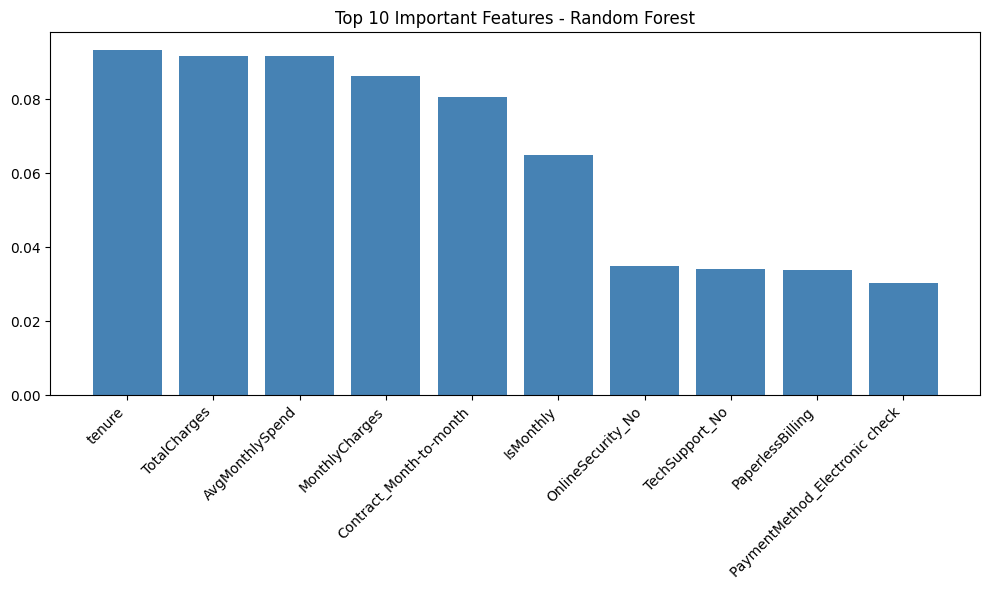

In [ ]:
# random forest gives feature importance
importances = best_rf.feature_importances_
feature_names = x_train.columns

# sort and pick top 10
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10,6))
plt.bar(range(10), importances[indices], color='steelblue')
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 10 Important Features - Random Forest')
plt.tight_layout()
plt.show()

Best Model: Random Forest

Random Forest was selected as the best model because:
1. It has high ROC-AUC score close to KNN
2. It gives feature importance which helps business decisions
3. It is faster and more practical for real world use
4. It supports SHAP values for model explanation
5. It is less sensitive to noise compared to KNN